In [1]:
import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d
import torch

import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../GP_regr')
sys.path.append('../nn_model')
sys.path.append('../data')
sys.path.append('..')


import plot_settings
import importlib
import SR_lib
#import multi_exp_log
#import Param_symbol

import GP
import nn_model_lib as _lib

from nn_model_lib import *


from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(GP)
    importlib.reload(_lib)
    importlib.reload(SR_lib)

COLORS = plot_settings.colors()

import_reload()


GP_FIT = GP.GP_process()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
RUN_ID = 'SP'

DT = 1
Q0 = 17921.57581 
L0 = 14.37325  # cell length [1e-5m]
SAVE  = False

REF_VALUES = SR_lib.get_ref_values(run_id=RUN_ID)


LIMS = {
    'R0': (1e-3, 0.1),
    'R1': (5e-3, 0.5),
    'C1': (1e2, 2.5e4),
    'k':  (0.1, 10.0),
    's':  (0.01, 1.0)
    }

def read_data(file_name):
    df = pd.read_csv(f"{file_name}.txt", sep=';', comment="%")
    return df

In [3]:
# Alternaitvely load model as GLOBAL
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'

BAT_MODEL, ckpt = load_nn_model(model_name)
history, CONFIG, N_HIDDEN, EPOCHS = load_checkpoint(ckpt)
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def NN_prediction(traj, model = BAT_MODEL, config = CONFIG, ret_elem = False):
    res = predict_np(model,config,traj)
    if ret_elem:
        return res['V'], res['soc'], res['R0'], res['R1'], res['C1'], res['k']
    else:
        return res['V'], res['soc']
    
def NN_prediction_F(traj, model = BAT_MODEL, config = CONFIG, ret_elem = False):
    res = predict_np(model,config,traj)
    if ret_elem:
        return res['V'], res['soc'], res['R0'], res['R1'], res['C1'], res['k'], res['s']
    else:
        return res['Fr'], res['soc'], res['s']

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using Q0_ckpt = 17921.57581, I_ref = 24.89107751102174 and u_ref = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained


In [4]:
expressions = SR_lib.extract_expressions(RUN_ID)
chosen_SR, best_SR = SR_lib.get_SR_inds(RUN_ID)

R0_expr = expressions['R0'][best_SR['R0']]; R1_expr = expressions['R1'][best_SR['R1']]; C1_expr = expressions['C1'][best_SR['C1']]
k_expr = expressions['k'][best_SR['k']]; s_expr = expressions['sdot'][best_SR['sdot']]
Ue_expr = expressions['Ue'][best_SR['Ue']]

R0_func = sp.lambdify(('C', 'd', 'soc'), R0_expr, 'numpy')
R1_func = sp.lambdify(('C', 'd', 'soc'), R1_expr, 'numpy')
C1_func = sp.lambdify(('C', 'd', 'soc'), C1_expr, 'numpy')

k_func = sp.lambdify(('C', 'd', 'soc'), k_expr, 'numpy')
sdot_func = sp.lambdify(('C', 'd', 'soc', 's'), s_expr, 'numpy')
Ueq_func = sp.lambdify(('soc'), Ue_expr, 'numpy')


In [5]:
display(Math(r'\LARGE \mathrm{Expressions:}'))

display(Math(f'\\large f_{{R_0}} = {sp.latex(sp.sympify(R0_expr).evalf(3))}'))
display(Math(f'\\large f_{{R_1}}= {sp.latex(sp.sympify(R1_expr).evalf(3))}'))
display(Math(f'\\large f_{{C_1}} = {sp.latex(sp.sympify(C1_expr).evalf(3))}'))
display(Math(f'\\large f_k = {sp.latex(sp.sympify(k_expr).evalf(3))}'))
display(Math(f'\\LARGE f_{{\\dot s}} = {sp.latex(sp.sympify(s_expr).evalf(3))}'))
display(Math(f'\\LARGE f_{{U}} = {sp.latex(sp.sympify(Ue_expr).evalf(3))}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:

    

def ecm_solve_fix(theta, I, t, U0=0.0):
    """Integrate ECM with constant [R0, R1, C1]. Return eta(t)."""
    R0, R1, C1 = theta
    I_interp = interp1d(t, I, fill_value='extrapolate')
    def dU1(u, t_):
        return -u / (R1 * C1) + I_interp(t_) / C1
    U1 = scipy.integrate.odeint(dU1, U0, t).flatten()
    return I * R0 + U1

def fit_ecm_fix(tr_ref, *, DC=True, p0=(0.01, 0.05, 5000), lims=LIMS):
    """Fit constant [R0, R1, C1] on one reference trajectory."""
    bounds = ([lims['R0'][0], lims['R1'][0], lims['C1'][0]],
              [lims['R0'][1], lims['R1'][1], lims['C1'][1]])
    if DC:
        xdata = [tr_ref['t'].numpy(), tr_ref['I']*np.ones_like(tr_ref['t'])]
    else:
        xdata = [tr_ref['t'].numpy(), tr_ref['I_seq'].numpy()] if 'I_seq' in tr_ref else [tr_ref['t'].numpy(), tr['I'].numpy()]
    eta = np.asarray(tr_ref['eta'])
    def _fwd(x, R0, R1, C1):
        _t, _I = x
        return ecm_solve_fix((R0, R1, C1), _I, _t)
    popt, _ = scipy.optimize.curve_fit(_fwd, xdata, eta,
                                       p0=list(p0), bounds=bounds)
    return popt                                   # ndarray([R0, R1, C1])

def predict_ecm_fix(tr, theta):
    """Apply fitted theta to any trajectory; V_B sampled at tr['t']."""
    t = np.asarray(tr['t'])
    I = np.asarray(tr['I_seq'] if 'I_seq' in tr
                   else float(tr['I']) * np.ones_like(t))
    return -ecm_solve_fix(theta, I, t) + np.asarray(tr['Ue'])

In [7]:
import scipy.signal as signal

def R0_calc(C_rate, d_per, SOC, NN = False, REF_VALUES = REF_VALUES, R0_func = R0_func):
    if NN:
        return R0_nn((C_rate), d_per, SOC)
    else:
        C_rate =  abs(C_rate / REF_VALUES['C'])
        d_per = abs(d_per /  REF_VALUES['d'])
        return R0_func(C_rate, d_per, SOC) * REF_VALUES['R0']

def R1_calc(C_rate, d_per, SOC,R1_func = R1_func, Ref= REF_VALUES,NN = False):
    if NN:
        return R1_nn((C_rate), d_per, SOC)
    else:
        C_rate =  abs(C_rate / REF_VALUES['C'])
        d_per = abs(d_per /  REF_VALUES['d'])
        return R1_func(C_rate, d_per, SOC) * Ref['R1']

def C1_calc(C_rate, d_per, SOC ,C1_func = C1_func, Ref= REF_VALUES, NN = False):
    if NN:
        return C1_nn((C_rate), d_per, SOC)
    else:
        C_rate =  abs(C_rate / REF_VALUES['C'])
        d_per = abs(d_per /  REF_VALUES['d'])
        return (C1_func(C_rate, d_per, SOC) * Ref['C1'])

def k_calc(C_rate, d_per, SOC, NN = False, Ref= REF_VALUES, k_func = k_func):
    if NN:
        return k_nn((C_rate), d_per, SOC)
    else:
        C_rate =  abs(C_rate / REF_VALUES['C'])
        d_per = abs(d_per /  REF_VALUES['d'])
        return k_func(C_rate, d_per, SOC) * REF_VALUES['k']
    
def sdot_calc(C_rate, d_per, SOC, s, NN = False, Ref= REF_VALUES): #, sdot_func = sdot_func):
    if NN:
        return sdot_nn((C_rate), d_per, SOC, s)
    else:
        C_rate =  abs(C_rate / REF_VALUES['C'])
        d_per = abs(d_per /  REF_VALUES['d'])
        s = (s / REF_VALUES['s'])
        return sdot_func(C_rate, d_per, SOC, s) * Ref['sdot']


def time_current_profile(C_rate,mode = 'DC'):
    I_0 = C_rate * Q0 / 3600
    if mode == 'DC':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = I_0 * np.ones_like(t)
        return I,t
    elif mode == 'pulse':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = signal.square(2 * np.pi * t / (3600 / C_rate)) * I_0 / 2 + I_0 / 2
        return I,t


def pulse_current_profile(t, C_rate):
    period =2 * 3600 *0.95 / C_rate
    I_0 = C_rate * Q0 / 3600
    I = I_0 * (signal.square(2 * np.pi * t / period)) #+ I_0*0.5 * (signal.square(2 * np.pi * t / (period * 0.1)))
    return I

In [8]:
def get_valid_indices(soc, V_B, soc_min=0.0, soc_max=1, V_min=0, V_max=6):
    return np.where((soc >= soc_min) & (soc <= soc_max) & (V_B >= V_min) & (V_B <= V_max))[0]


def solve_multi_physics(u_par,C_rate, U0 = 0, mode = 'DC', NN = False, 
                        tmax = None, I_profile = None, BB = False, DT =1, SR_ue = False):
    d_per = u_par
    if tmax is not None:
        t = np.arange(0, tmax, DT)
    else:
        #t = np.arange(0, 2 * int(3600 / C_rate), DT)
        t_len = int(3600 / C_rate) / DT
        t = np.linspace(0,int(3600 / C_rate), t_len)
    if I_profile is None:
        i = C_rate * Q0 / 3600 * np.ones_like(t)  # Assuming constant current for simplicity

    if mode == 'pulse':
        i = pulse_current_profile(t, C_rate)

    if I_profile is not None and tmax is not None:
        I_interp = interp1d(t, I_profile, fill_value="extrapolate")
        i = I_interp(t)

    def mult_dynamics(y,t_, d_per, NN, i = i):
        SOC, U1, s = y
        I_t = np.interp(t_, t, i)
        SOC_eff = np.clip(SOC, 1e-6, 1 - 1e-6)

        sign = np.sign(I_t)
        if NN:
            R = R1_calc((I_t * 3600/Q0), d_per, SOC_eff, NN = NN)[0]
            C = C1_calc((I_t * 3600/Q0), d_per, SOC_eff, NN = NN)[0]
            sdot = sign * sdot_calc(abs(I_t * 3600/Q0), d_per, SOC_eff, s, NN = NN)
        else:
            R = R1_calc(I_t * 3600/Q0, d_per, SOC_eff, NN = NN)
            C = C1_calc(I_t * 3600/Q0, d_per, SOC_eff, NN = NN)
            sdot = sign * sdot_calc(abs(I_t * 3600/Q0), d_per, SOC_eff, s, NN = NN)

        dSOC_dt = -I_t / Q0
        dU1_dt = -U1 / (R * C) + I_t / C
        ds_dt = sdot

        return [dSOC_dt, dU1_dt, ds_dt]
    soc0 = 1 
    y0 = [soc0, U0, 0]
    sol = scipy.integrate.odeint(mult_dynamics, y0, t, args=(d_per, NN))
    SOC_t = sol[:, 0]
    R_0 = R0_calc(i * 3600/Q0, d_per, SOC_t, NN = NN)
    U1 = sol[:, 1]
    s = sol[:, 2]
    eta = i * R_0 + U1
    
    if SR_ue:
        Ue = Ueq_func(SOC_t)
    else:
        Ue = GP.soc_to_Ue(SOC_t, GP_FIT)
    V_B = Ue - eta

    valid_inds = get_valid_indices(SOC_t, V_B)

    V_B = V_B[valid_inds]
    t = t[valid_inds]
    soc = SOC_t[valid_inds]
    Ue = GP.soc_to_Ue(soc, GP_FIT)
    i = i[valid_inds]
    F = k_calc(abs(i * 3600/Q0), d_per, soc, NN = NN) * (s[valid_inds] + d_per/100 * L0)
    res = {
        'V_B': V_B,
        'soc': soc,
        'Ue': Ue,
        'i': i,
        't': t,
        'F': F
    }
    return res


In [9]:

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap
from matplotlib.colors import LinearSegmentedColormap

def plot_mosaic_predicts_report(trajs,model= BAT_MODEL,config=CONFIG, *, predict='V', sort='C_rate',
                                n_show=5, pulse=False, fixed=True, start=0, Q0=17921.57581, SR = False):
    """Two-panel (pulse) or single-panel (CC) prediction-vs-data plot.

    True trajectories are dashed (Reds); NN predictions are solid (Blues).
    Each trajectory's shade encodes `sort` (C-rate or u_per) via `norm`.

    pulse=True  → current panel (top, compact) + prediction panel (bottom),
                  shared colorbar across both.
    pulse=False → prediction panel only, with a fixed-value tag.
    
    """
    assert predict in ('V', 'F'), "predict must be 'V' or 'F'"
    model.eval()

    if sort == 'C_rate':
        trajs_sorted = sorted(trajs, key=lambda tr: tr['C'])
        vals_arr = np.array([tr['C'] for tr in trajs_sorted])
        bar_name = 'C-rate [1/h]'
    elif sort == 'u_per':
        trajs_sorted = sorted(trajs, key=lambda tr: tr['u_per'])
        vals_arr = np.array([tr['u_per'] for tr in trajs_sorted])
        bar_name = r'$\widetilde{d}$ [\%]'
    else:
        raise ValueError(f"sort must be 'C_rate' or 'u_per', got {sort!r}")
    norm = Normalize(vmin=vals_arr.min(), vmax=vals_arr.max())

    if n_show is None or n_show >= len(trajs_sorted):
        trajs_plot = trajs_sorted
    else:
        # start = start if pulse else 0
        idx = np.unique(np.linspace(start, len(trajs_sorted) - 1, n_show).round().astype(int))
        trajs_plot = [trajs_sorted[i] for i in idx]

    # True → Reds, Predicted → Blues (regardless of `sort`)
    base = plt.cm.Blues_r
    cmap_b = LinearSegmentedColormap.from_list(
        "Blues_custom", base(np.linspace(0.0, 0.7, 256)))
    base = plt.cm.Reds_r
    cmap_r = LinearSegmentedColormap.from_list(
        "Reds_custom", base(np.linspace(0.0, 0.7, 256)))

    # ── layout ─────────────────────────────────────────────────────────
    if pulse:
        fig, ax = plt.subplot_mosaic(
            [['current'], ['voltage']],
            figsize=(4.3, 3.5),
            height_ratios=[0.4, 1.0],
            sharex=True, constrained_layout=True,
        )
        ax_i, ax_v = ax['current'], ax['voltage']
    else:
        fig, ax_v = plt.subplots(figsize=(4.3, 3.1), constrained_layout=True)
        ax_i = None

    I_to_C = 3600.0 / Q0

    # ── plot ───────────────────────────────────────────────────────────

    

    with torch.no_grad():
        for tr in trajs_plot:
            bar_val = float(tr['C']) if sort == 'C_rate' else float(tr['u_per'])
            color_true = cmap_r(norm(bar_val))
            color_true = 'black'
            color_pred = cmap_b(norm(bar_val))
            
            if SR:
                if pulse:
                    I = tr['I_seq'].numpy() if hasattr(tr['I_seq'], 'numpy') else np.asarray(tr['I_seq'])
                else: 
                    I = None
                res_sr = solve_multi_physics(float(tr['u_per']), float(tr['C']), NN = False, tmax = tr['T']*DT, I_profile = I)
            out = predict_np(model, config, tr)
            t = np.arange(tr['T'])

            if predict == 'V':
                if SR:
                    y_pred = res_sr['V_B']
                    y_true = out['V']
                else:
                    y_true = tr['V'].numpy() if hasattr(tr['V'], 'numpy') else np.asarray(tr['V'])
                    y_pred = out['V']
            else:  # 'F
                if SR:
                    y_pred = res_sr['F'] * 1000 # GN – MN
                    y_true = out['Fr'] * 1000 # GN – MN
                else:
                    y_true = tr['F'].numpy() * 1000 if hasattr(tr['F'], 'numpy') else np.asarray(tr['F']) * 1000  # GN – MN
                    y_pred = out['Fr'] * 1000 # GN – MN

            ax_v.plot(t, y_pred, '-',  color=color_pred, lw=2, alpha=0.9)
            ax_v.plot(t, y_true, '--', color=color_true, lw=2, alpha=0.5)

            if pulse:
                if 'I_seq' not in tr:
                    raise ValueError(
                        "pulse=True but trajectory has no 'I_seq' — did you use "
                        "prepare_data instead of prepare_pulse_data?")
                I = tr['I_seq'].numpy() if hasattr(tr['I_seq'], 'numpy') else np.asarray(tr['I_seq'])
                # Current is the same for true & pred — single line, neutral shade
                ax_i.plot(t, I * I_to_C, color=color_pred, lw=2, alpha=0.9)

    ax_v.set_ylabel(r'$V_B$ [V]' if predict == 'V' else r'$F$ [MN]')
    ax_v.set_xlabel('Time [s]')

    # Fixed-value tag — value of the variable not being swept
    first = trajs_plot[0]
    if sort == 'u_per':
        tag = fr'${float(first["C"]):g}$C'
    else:  # sort == 'C_rate'
        tag = fr'$\widetilde{{d}} = {float(first["u_per"]):g}\%$'
    if SR:
        handles = [
            plt.Line2D([0], [0], color='black',  lw=2, linestyle='--', label='NN', alpha=0.5),
            plt.Line2D([0], [0], color='tab:blue', lw=2, linestyle='-',  label='SR')]
    else:
        handles = [
            plt.Line2D([0], [0], color='black',  lw=2, linestyle='--', label='True', alpha=0.5),
            plt.Line2D([0], [0], color='tab:blue', lw=2, linestyle='-',  label='Predicted')]
    if fixed:
        handles.append(plt.Line2D([0], [0], color='none', label=tag))
    ax_v.legend(handles=handles, loc='upper right', frameon=True,
                handlelength=1.5, handletextpad=0.5, fontsize=14)

    if pulse:
        ax_i.set_ylabel('Cr [1/h]')

    sm = ScalarMappable(cmap=cmap_b, norm=norm)   # colorbar shows the Predicted palette
    sm.set_array([])
    cbar_ax = [ax_i, ax_v] if pulse else ax_v
    fig.colorbar(sm, ax=cbar_ax, label=bar_name, location='right', pad=0.01)

    return fig

14400 14400
2.165332091120036 4.714303146118191


Text(0, 0.5, 'Voltage [V]')

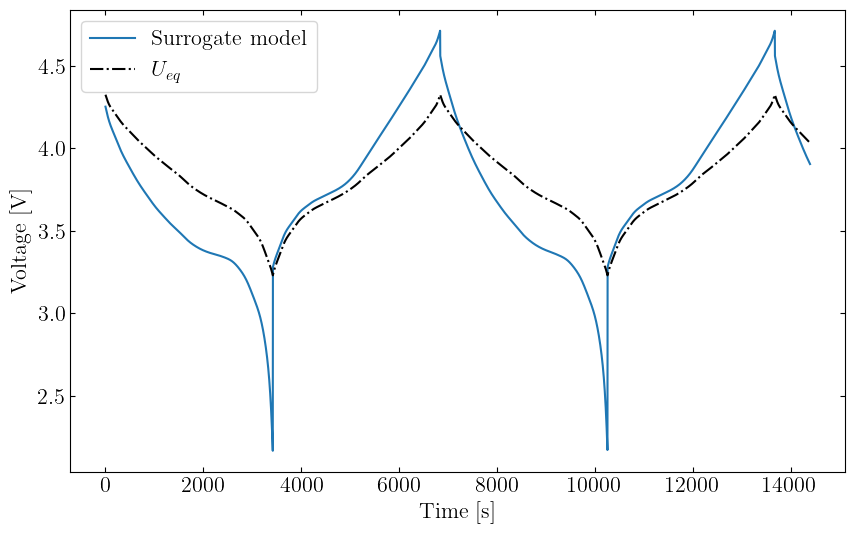

In [28]:
C = 1
res = solve_multi_physics(0, C, mode='pulse', NN = True, tmax = 3600 * 4/C, DT = 1/C, SR_ue = False)
print(len(res['V_B']), len(res['t']))

print(res['V_B'].min(), res['V_B'].max())

plt.figure(figsize=(10, 6))

plt.plot(res['t'], res['V_B'], label='Surrogate model')
plt.plot(res['t'], res['Ue'], color = 'black', linestyle = '-.', label = r'$U_{eq}$')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')

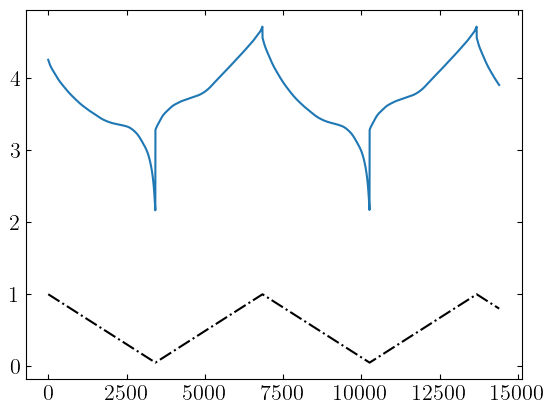

In [ ]:


# plt.plot(res['t'], res['V_B'], label='Surrogate model')
# plt.plot(res['t'], res['soc'], color = 'black', linestyle = '-.', label = r'$U_{eq}$')

14400 14400
2.165332091120036 4.714303146118191


Text(0, 0.5, 'Force [MN]')

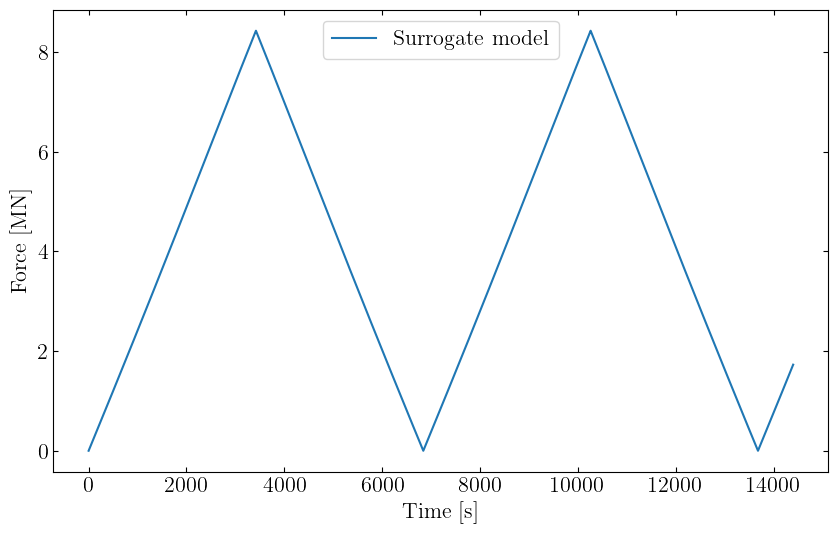

In [12]:
C = 1
res = solve_multi_physics(0, C, mode='pulse', NN = True, tmax = 3600 * 4/C, DT = 1/C, SR_ue = False)
print(len(res['V_B']), len(res['t']))

print(res['V_B'].min(), res['V_B'].max())

plt.figure(figsize=(10, 6))

plt.plot(res['t'], res['F'] * 1000, label='Surrogate model')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Force [MN]')

,u_par,C,t,V,F,u,Ue,soc,I,eta,pulse,trajectory
0,27.9,2.75,0,4.215052,0.131997,-4.010137,4.324995,0.999998,13.690093,0.109944,False,1
1,27.9,2.75,1,4.180852,0.132017,-4.010137,4.322674,0.999236,13.690093,0.141822,False,1
2,27.9,2.75,2,4.162011,0.132030,-4.010137,4.320348,0.998472,13.690093,0.158337,False,1
3,27.9,2.75,3,4.153260,0.132042,-4.010137,4.318022,0.997708,13.690093,0.164762,False,1
4,27.9,2.75,4,4.146008,0.132055,-4.010137,4.315696,0.996944,13.690093,0.169687,False,1


F_max in test set: 0.15 
Using COMSOL OCV model for Ue


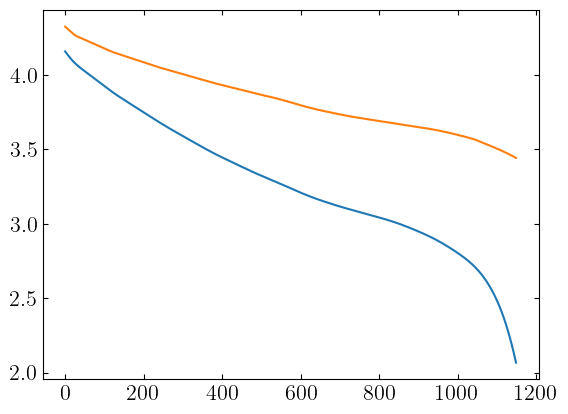

In [ ]:
other_combo_data = read_data(f'{Path().absolute()}/../data/polished_combo/combo_other_half')
display(other_combo_data.head())


print(f'F_max in test set: {other_combo_data["F"][other_combo_data['t'] == 0].max():.2f} ') 

df_dc = other_combo_data[other_combo_data['pulse'] == False]
df_pulse = other_combo_data[other_combo_data['pulse'] == 1]


Trajectories in test set: 
[  1   3   5   9  11  13  15  17  19  21  23  27  35  37  39  43  45  51
  53  59  63  69  71  75  77  79  83  85  89  91  95  97 103 105 107 109
 111 113 117 121 125 127 133 135 139 141 147 151 153 159 161 163 165 167
 171 173 177 183 189 193 195 197 203 205 207 211 213]
15
Selected trajectory: 15 with C=0.56 and u_par=26.5
22
Selected trajectory: 22 with C=4.98 and u_par=22.9


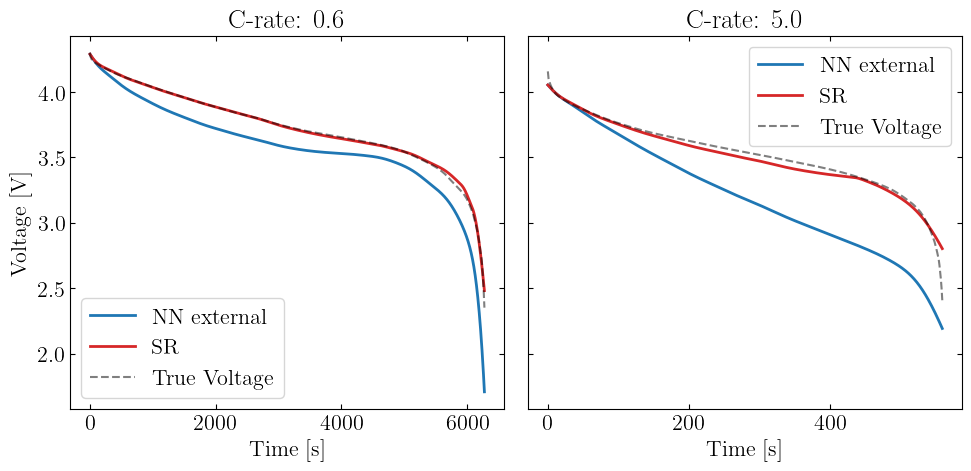

In [14]:
print(f'Trajectories in test set: ')


df = df_dc
print(df['trajectory'].unique())
trajs = prepare_data(df)
u_C_pairs = df.loc[df['t'] == 0, ['u_par', 'C', 'trajectory']]

f,ax = plt.subplots(1,2, figsize=(10,5), sharey=True)

for j,C in enumerate([.5, 5.]):

    traj = int(np.argmin(np.abs(u_C_pairs['C'] - C))) 
    print(traj)
    C_ext = trajs[traj]['C']
    u_par_ext = trajs[traj]['u_per']
    soc_init = trajs[traj]['soc'][0]
    print(f"Selected trajectory: {traj} with C={C_ext} and u_par={u_par_ext}")
    traj_full = trajs[traj]
    t_max = traj_full['T']
    t_traj = np.arange(0, t_max, DT)

    i = traj_full['I'] * np.ones_like(t_traj)

    res = solve_multi_physics(u_par_ext,C_ext, mode = 'DC', NN = True, tmax =t_max, I_profile = i)
    t = res['t']
    V_B = res['V_B']

    ax[j].plot(t, V_B, label='NN external', lw = 2, color = COLORS[0])

    res = solve_multi_physics(u_par_ext,C_ext,  mode = 'DC', NN = False, tmax =t_max, I_profile = i)
    t = res['t']; V_B = res['V_B']
    ax[j].plot(t, V_B, label='SR', lw = 2, color = COLORS[1])
    ax[j].plot(t_traj,traj_full['V'], label='True Voltage', color = 'k', ls = '--', alpha = .5)

    ax[j].set_xlabel('Time [s]')
    ax[j].set_title(f'C-rate: {C_ext:.1f}')
    ax[j].legend()
ax[0].set_ylabel('Voltage [V]')
plt.tight_layout()
#plt.savefig('SR_figs/ecm_fit.pdf')

In [15]:
other_combo_pulse_d0 = prepare_pulse_data(other_combo_data[(other_combo_data['u_par']==0) & (other_combo_data['pulse'] == True)])

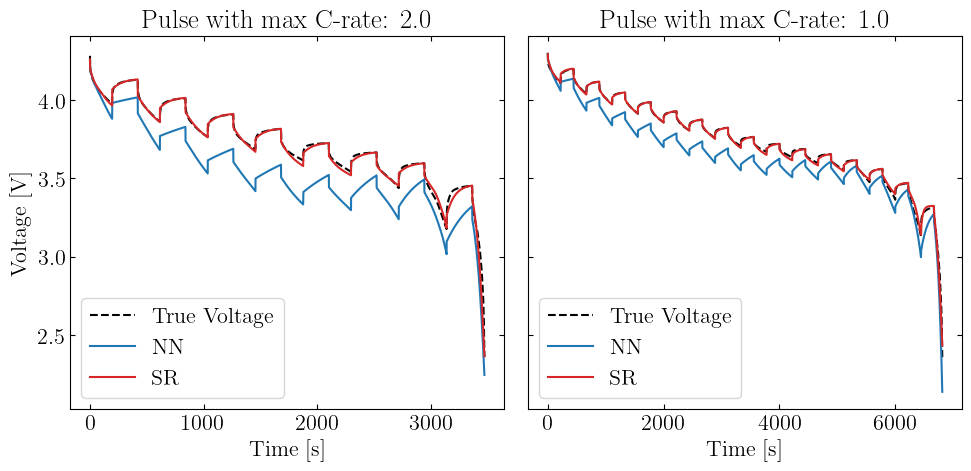

In [16]:
uc_pulse_pairs = df_pulse.loc[df_pulse['t'] == 0, ['u_par', 'C', 'trajectory']]
trajs_pulse = prepare_pulse_data(df_pulse)

f,ax = plt.subplots(1,2, figsize=(10,5), sharey=True)

for j,C in enumerate([2., 1.]):

    traj = int(np.argmin(np.abs(uc_pulse_pairs['C'] - C))) 
    C_ext = uc_pulse_pairs['C'].values[traj]
    u_par_ext = uc_pulse_pairs['u_par'].values[traj]


    traj_full = trajs_pulse[traj]
    i = traj_full['I_seq']

    ax[j].plot(traj_full['t'], traj_full['V'], label='True Voltage', color = 'k', ls = '--')
    tmax = traj_full['t'][-1].numpy()

    res = solve_multi_physics(u_par_ext,C_ext, mode = 'pulse', NN = True, tmax =tmax+1, I_profile = i)
    t = res['t']; VB = res['V_B']
    ax[j].plot(t, VB, label='NN', color = COLORS[0])
    res = solve_multi_physics(u_par_ext,C_ext,  mode = 'pulse', NN = False, tmax =tmax+1 , I_profile = i)
    #VB, soc,Ue,i,t = ECM_solve_du(u_par_ext,C_ext, discharge = True, tmax = df_pulse.loc[df_pulse['trajectory'] == traj, 't'].max(), I_profile = i, NN = False)
    t = res['t']; VB = res['V_B']
    ax[j].plot(t, VB, label='SR', color = COLORS[1])
    ax[j].legend()
    
    ax[j].set_title(f'Pulse with max C-rate: {C_ext:.1f}')
    ax[j].set_xlabel('Time [s]')
ax[0].set_ylabel('Voltage [V]')
plt.tight_layout()
# plt.savefig('ecm_pulse_fit.pdf')

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using Q0_ckpt = 17921.57581, I_ref = 24.89107751102174 and u_ref = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained
Fix-ECM fit on C=3.22, u_per=0.00:  R0=0.0105 Ohm,  R1=0.0081 Ohm,  C1=25000.0 F
Plotted C-rates: ['1.64', '2.30', '3.22', '4.12', '4.81']
Plotted C-rates: ['1.64', '2.30', '3.22', '4.12', '4.81']
Plotted C-rates: ['1.64', '2.30', '3.22', '4.12', '4.81']
Plotted C-rates: ['1.64', '2

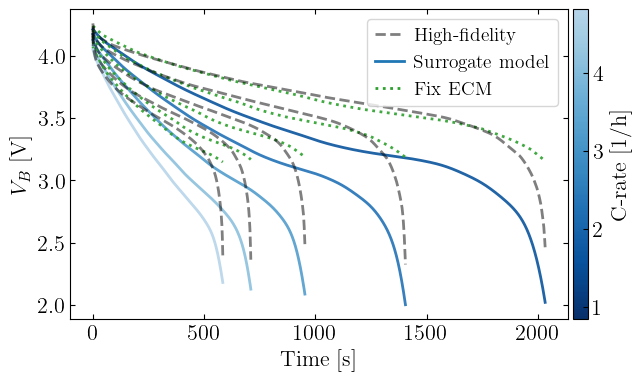

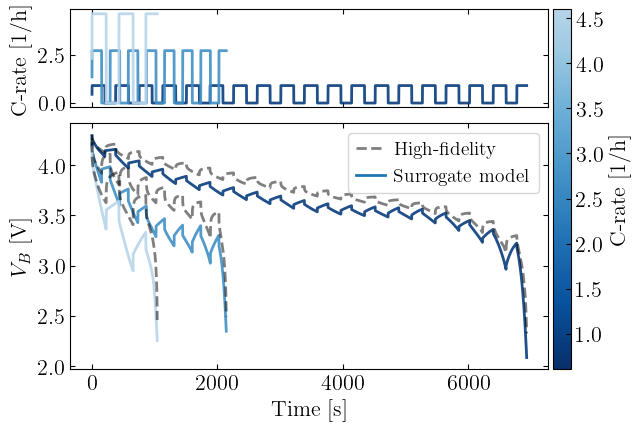

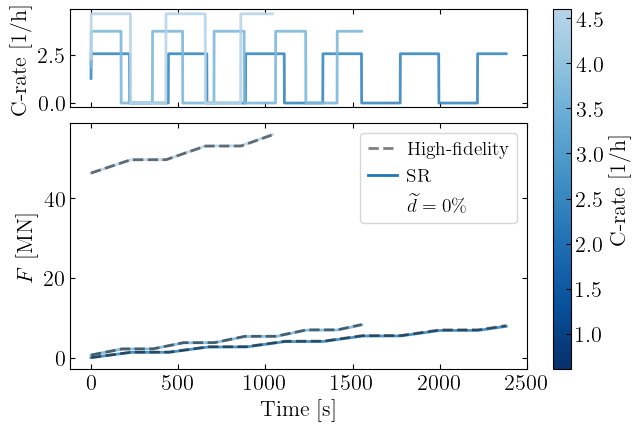

In [17]:
# ── Model load ──────────────────────────────────────────────────────────
MODEL_NAME = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'
BAT_MODEL, _ckpt = load_nn_model(MODEL_NAME)
_history, CONFIG, _N_HIDDEN, _EPOCHS = load_checkpoint(_ckpt)
BAT_MODEL.eval()

# ── Constant-parameter 1-RC ECM solver ──────────────────────────────────


# ── Mosaic plot: True · NN · (SR) · (Fix-ECM) overlay ───────────────────
def plot_mosaic_predicts_report(
    trajs, model=BAT_MODEL, config=CONFIG, *,
    predict='V', sort='C_rate', n_show=5,
    pulse=False, fixed=True, start=0,
    SR=False, ECM_fix=False, fix_ref_C=None,
):
    assert predict in ('V', 'F')
    model.eval()

    # Sort / subselect ─────────────────────────────────────────────────
    if sort == 'C_rate':
        trajs_sorted = sorted(trajs, key=lambda tr: tr['C'])
        vals = np.array([tr['C'] for tr in trajs_sorted])
        bar_name = 'C-rate [1/h]'
    elif sort == 'u_per':
        trajs_sorted = sorted(trajs, key=lambda tr: tr['u_per'])
        vals = np.array([tr['u_per'] for tr in trajs_sorted])
        bar_name = r'$\widetilde{d}$ [\%]'
    else:
        raise ValueError(f"sort must be 'C_rate' or 'u_per', got {sort!r}")
    norm = Normalize(vmin=vals.min(), vmax=vals.max())

    if n_show is None or n_show >= len(trajs_sorted):
        trajs_plot = trajs_sorted
    else:
        idx = np.unique(np.linspace(start, len(trajs_sorted) - 1,
                                    n_show).round().astype(int))
        trajs_plot = [trajs_sorted[i] for i in idx]

    cmap_b = LinearSegmentedColormap.from_list(
        "Blues_custom", plt.cm.Blues_r(np.linspace(0.0, 0.7, 256)))

    # Fit Fix-ECM once on reference trajectory ─────────────────────────
    theta_fix = None
    if ECM_fix and predict == 'V':
        if fix_ref_C is not None:
            ref_tr = min(trajs_plot, key=lambda t: abs(float(t['C']) - fix_ref_C))
        else:
            ref_tr = min(trajs_plot, key=lambda t: float(t['C']))
        theta_fix = fit_ecm_fix(ref_tr, DC=not pulse)
        print(f"Fix-ECM fit on C={float(ref_tr['C']):.2f}, "
              f"u_per={float(ref_tr['u_per']):.2f}:  "
              f"R0={theta_fix[0]:.4f} Ohm,  R1={theta_fix[1]:.4f} Ohm,  "
              f"C1={theta_fix[2]:.1f} F")

    # Layout ──────────────────────────────────────────────────────────
    if pulse:
        fig, axs = plt.subplot_mosaic(
            [['current'], ['voltage']],
            figsize=(6.3, 4.2), height_ratios=[0.4, 1.0],
            sharex=True, constrained_layout=True,
        )
        ax_i, ax_v = axs['current'], axs['voltage']
    else:
        fig, ax_v = plt.subplots(figsize=(6.3, 3.7), constrained_layout=True)
        ax_i = None
    I_to_C = 3600.0 / Q0

    # Trajectory loop ─────────────────────────────────────────────────
    with torch.no_grad():
        for tr in trajs_plot:
            bar_val = float(tr['C']) if sort == 'C_rate' else float(tr['u_per'])
            print("Plotted C-rates:", [f"{float(tr['C']):.2f}" for tr in trajs_plot])
            color_pred = cmap_b(norm(bar_val))

            if SR:
                I_sr = np.asarray(tr['I_seq']) if pulse else None
                res_sr = solve_multi_physics(
                    float(tr['u_per']), float(tr['C']), NN=False,
                    tmax=tr['T'] * DT, I_profile=I_sr,
                )
            out = solve_multi_physics(float(tr['u_per']), float(tr['C']), NN=True,
                                      tmax=tr['T'] * DT, I_profile=tr['I_seq'] if pulse else None)
            #predict_np(model, config, tr)
            t_idx = np.arange(tr['T'])

            if predict == 'V':
                # y_true = out['V'] if SR else np.asarray(tr['V'])
                y_true = np.asarray(tr['V'])    # HF data
                y_pred = res_sr['V_B'] if SR else out['V_B']
            else:
                # y_true = (out['Fr'] if SR else np.asarray(tr['F'])) * 1000
                y_true = (np.asarray(tr['F'])) * 1000   # HF data
                y_pred = (res_sr['F'] if SR else out['Fr']) * 1000

            # back to front:  Fix-ECM, NN/SR, then True on top
            if theta_fix is not None:
                y_fix = predict_ecm_fix(tr, theta_fix)
                ax_v.plot(t_idx, y_fix, ':',  color='tab:green',
                          lw=2, alpha=0.9)
            ax_v.plot(t_idx[:len(y_pred)], y_pred, '-',
                      color=color_pred, lw=2, alpha=0.9)
            ax_v.plot(t_idx, y_true, '--', color='black', lw=2, alpha=0.5)

            if pulse:
                I_show = np.asarray(tr['I_seq'])
                ax_i.plot(t_idx, I_show * I_to_C,
                          color=color_pred, lw=2, alpha=0.9)


    ax_v.set_ylabel(r'$V_B$ [V]' if predict == 'V' else r'$F$ [MN]')
    ax_v.set_xlabel('Time [s]')
    first = trajs_plot[0]
    tag = (fr'${float(first["C"]):g}$C' if sort == 'u_per'
           else fr'$\widetilde{{d}} = {float(first["u_per"]):g}\%$')

    label_true, label_pred = ('High-fidelity', 'SR') if SR else ('High-fidelity', 'Surrogate model')
    handles = [
        plt.Line2D([0], [0], color='black',    lw=2, ls='--', alpha=0.5,
                   label=label_true),
        plt.Line2D([0], [0], color='tab:blue', lw=2, ls='-',  label=label_pred),
    ]
    if theta_fix is not None:
        handles.append(plt.Line2D([0], [0], color='tab:green', lw=2, ls=':',
                                  label='Fix ECM'))
    if fixed:
        handles.append(plt.Line2D([0], [0], color='none', label=tag))
    ax_v.legend(handles=handles, loc='best', frameon=True,
                handlelength=1.5, handletextpad=0.5, fontsize=14)

    if pulse:
        ax_i.set_ylabel('C-rate [1/h]')
    sm = ScalarMappable(cmap=cmap_b, norm=norm); sm.set_array([])
    fig.colorbar(sm, ax=([ax_i, ax_v] if pulse else ax_v),
                 label=bar_name, location='right', pad=0.01)
    return fig



trajs_dc = prepare_data(df_dc[df_dc['u_par'] == 0])
trajs_pulse = prepare_pulse_data(df_pulse)

fig = plot_mosaic_predicts_report(trajs_dc, predict='V', n_show=5, pulse=False,
                                    SR=False, ECM_fix=True, fix_ref_C=3.5, start=3, fixed=False)
# plt.savefig('ecm_fit_nn.pdf')
fig = plot_mosaic_predicts_report(trajs_pulse, predict='V', n_show=3, pulse=True,
                                     SR=False, ECM_fix=False, fix_ref_C=3.5, start=3, fixed=False)
# plt.savefig('ecm_fit_nn_pulse.pdf')


fig = plot_mosaic_predicts_report(trajs_pulse, predict='F', n_show=3, pulse=True,
                                    SR=True, ECM_fix=False, fix_ref_C=3.5, start=20, fixed=True)




#fig = plot_mosaic_predicts_report(trajs_pulse_d0, predict='F', n_show=3, pulse=True,
 #                                   SR=True, ECM_fix=False, fix_ref_C=3.5, start=2, fixed=True)
#plt.savefig('SR_pulse_F.pdf')
plt.show()

tensor([ 4.9782,  4.9782,  4.9782,  ..., -4.9782, -4.9782, -4.9782])
Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'back_in_black', 'style_F': 'static'}
Using Q0_ckpt = 17921.57581, I_ref = 24.89107751102174 and u_ref = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
s constrained to [0.0, 0.5] 1e-5 m  (static sNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm
Pre-tabulating Ue(SOC) on 2000-point grid over [0.0, 1.05] ...
Loading GP for Comsol Ue(SOC) ...


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_42047/3337598932.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  charge_traj_abs['I_seq'] = np.abs(charge_traj_abs['I_seq'])


Using COMSOL OCV model for Ue
Fix-ECM theta on C=2.57, u_per=0.00:  R0=0.0115 Ohm,  R1=0.0070 Ohm,  C1=25000.0 F


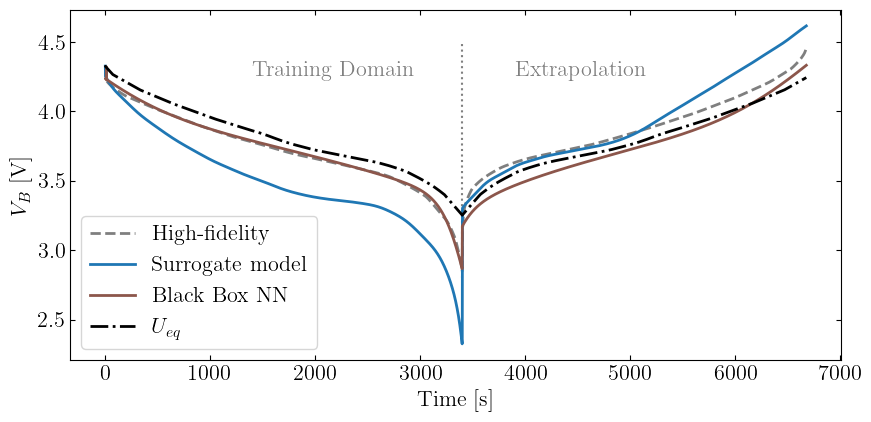

In [18]:
charge_test_df = pd.read_csv(f'{Path().absolute()}/../data/polished_pulse/data_discharge_charge.txt', sep=';')

I = charge_test_df['I'].values
t = charge_test_df['t'].values
charge_traj = prepare_pulse_data(charge_test_df)
print(charge_traj[0]['I_seq'])
tmax = t[-1]
Ue_data = charge_test_df['Ue'].values
V_true = charge_test_df['V'].values
#C = .5;u = 10

# u = 0; C = 1
model_name_bl = '0513_1625_b4_combo_V-back_in_black_F-static_R0c_C1c_7.19min_16h_2500eps.pt'
BLACK_MODEL, ckpt = load_nn_model(model_name_bl)
history, CONFIG_BLACK, N_HIDDEN, EPOCHS = load_checkpoint(ckpt)

# If Black Box is used with absolute crate it continues to lower voltages.
charge_traj_abs = charge_traj[0].copy()
charge_traj_abs['I_seq'] = np.abs(charge_traj_abs['I_seq'])

V_BBB = predict_np(BLACK_MODEL, CONFIG_BLACK, charge_traj[0], V_mode = 'back_in_black')['V']


# ––– SOLVE V & F –––
res_NN = solve_multi_physics(0, 1, NN = True, tmax = tmax+1, I_profile = I)
res_SR = solve_multi_physics(0, 1, NN = True, tmax = tmax+1, I_profile = I)

ref_tr    = min(trajs_dc, key=lambda t: abs(float(t['C']) - 2.5)) # Pick a reference trajectory as close as 2.5 C as possible.
theta_fix = fit_ecm_fix(ref_tr, DC=True)
print(f"Fix-ECM theta on C={float(ref_tr['C']):.2f}, "
      f"u_per={float(ref_tr['u_per']):.2f}:  "
      f"R0={theta_fix[0]:.4f} Ohm,  R1={theta_fix[1]:.4f} Ohm,  "
      f"C1={theta_fix[2]:.1f} F")
V_fix = predict_ecm_fix(charge_traj[0], theta_fix)


# ––– PLOT V –––
f, ax = plt.subplots(figsize=(9,4.5))
# extract t with lowest soc 
tmin_soc = t[np.argmin(charge_traj[0]['soc'])]
ax.vlines(tmin_soc, ymin=2.8, ymax=4.5, color = 'gray', ls = ':')
ax.text(tmin_soc+500, 4.25, 'Extrapolation', color = 'gray')
ax.text(tmin_soc-2000, 4.25, 'Training Domain', color = 'gray')

ax.plot(t, V_true, 'black', ls = '--', label='High-fidelity', alpha=0.5, lw = 2)
ax.plot(res_NN['t'], res_NN['V_B'], label='Surrogate model', color = 'tab:blue', lw = 2) 
ax.plot(t, V_BBB, label='Black Box NN', color = 'tab:brown', ls = '-',lw = 2) 
# ax.plot(t,V_fix, 'tab:green', ls = ':', label='Fix ECM', lw = 2)
ax.plot(t, Ue_data, 'black', ls = '-.', label=r'$U_{eq}$', lw = 2)
ax.set_xlabel('Time [s]')


ax.set_ylabel(r'$V_B$ [V]')
ax.legend()
plt.tight_layout()

#plt.savefig('Full_cycle_comp_nnV.pdf')

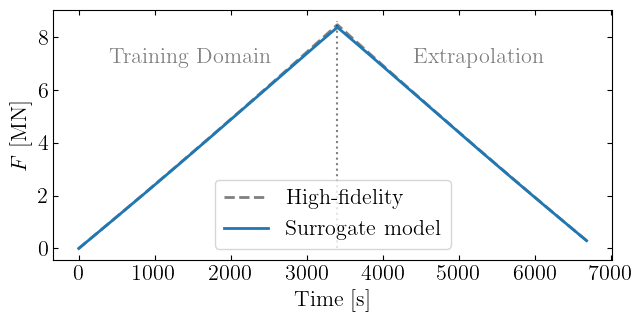

In [19]:
# ––– SOLVE F –––

# ––– PLOT F –––
f, ax = plt.subplots(figsize=(6.5,3.5))
tmin_soc = t[np.argmin(charge_traj[0]['soc'])]
ax.vlines(tmin_soc, ymin=0, ymax=8.6, color = 'gray', ls = ':')
ax.text(tmin_soc+1000, 7, 'Extrapolation', color = 'gray')
ax.text(tmin_soc-3000, 7, 'Training Domain', color = 'gray')

ax.plot(t, charge_test_df['F']*1000, label='High-fidelity', color = 'black', ls = '--', alpha=0.5, lw = 2)
ax.plot(res_NN['t'], res_NN['F'] * 1000, label='Surrogate model', color = 'tab:blue', ls = '-', lw = 2)
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$F$ [MN]')
ax.legend()
plt.tight_layout()
#plt.savefig('Full_cycle_F.pdf')

In [20]:
charge_test_df = pd.read_csv(f'{Path().absolute()}/../data/data_discharge_charge.txt', sep=';')

I = charge_test_df['I'].values
t = charge_test_df['t'].values
charge_traj = prepare_pulse_data(charge_test_df)
print(charge_traj[0]['I_seq'])
tmax = t[-1]
Ue_data = charge_test_df['Ue'].values
V_true = charge_test_df['V'].values
soc_charge = charge_traj[0]['soc']



def get_data_low():
    df = pd.read_csv(
        f"{Path().absolute()}/../GP_regr/GP_run.txt",
        sep=r"\s+",
        comment="%",
        header=None
    )

    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)','soc_cell (1)']
    df.columns = ['u_par', 'C', 't', 'V', 'I', 'F', 'u', 'Ue', 'soc']

    # Sort by time within each batch
    return df

df_low = get_data_low()


display(df_low.head())


def plot_data_vs_soc(trajs, *, predict='V', n_show=5, start=0, df_low = df_low):
      """Plot raw trajectory data (V or F) against SOC, colored by C-rate."""
      assert predict in ('V', 'F')

      # sort + sub-select by C-rate
      trajs_sorted = sorted(trajs, key=lambda tr: tr['C'])
      if n_show is None or n_show >= len(trajs_sorted):
            trajs_plot = trajs_sorted
      else:
            idx = np.unique(np.linspace(start, len(trajs_sorted) - 1,
                                    n_show).round().astype(int))
            trajs_plot = [trajs_sorted[i] for i in idx]

      C_vals = np.array([tr['C'] for tr in trajs_plot])
      norm = Normalize(vmin=C_vals.min(), vmax=C_vals.max())
      cmap = LinearSegmentedColormap.from_list(
            "Blues_custom", plt.cm.Blues_r(np.linspace(0.0, 0.7, 256)))

      fig, ax = plt.subplots(figsize=(5, 3.7), constrained_layout=True)

      for tr in trajs_plot:
            soc = np.asarray(tr['soc'])
            y   = np.asarray(tr['V'])
            m = y >= 2.45 # only plot points with V >= 2.7 V to avoid messy plot in low-voltage region
            soc = soc[m]
            y   = y[m]
            ax.plot(soc, y, '-', color=cmap(norm(float(tr['C']))), lw=2)

      # Reference Ue curve — only meaningful for the voltage plot
      tr_ref = trajs_plot[0]   # lowest C-rate (trajs_plot is sorted by C)
      ax.plot(np.asarray(df_low['soc'][df_low['Ue']>2.45]), np.asarray(df_low['Ue'][df_low['Ue']>2.45]), 'black', ls='-.', label=r'$U_{eq}$', lw=2)

      ax.legend(loc='best')
      ax.set_xlabel('State of Charge')
      ax.set_ylabel(r'$V_B$ [V]')
      ax.ticklabel_format(useOffset=False, style='plain', axis='y')

      sm = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
      fig.colorbar(sm, ax=ax, label='C-rate [1/h]',
                  location='right', pad=0.01)
      

      return fig, cmap


trajs_dc = prepare_data(df_dc)
print(df_dc.columns)
trajs_Ue = prepare_data(df_dc[df_dc['C'] == 0.5])
print(trajs_Ue)
trajs_pulse = prepare_pulse_data(df_pulse)

fig, cmap = plot_data_vs_soc(trajs_dc, predict='V', n_show=20, start=0)
#plt.savefig('V_soc.pdf')
# plt.tight_layout()
plt.show()


# # ––– PLOT V –––
f, ax = plt.subplots(figsize=(5,3.7))


# Ue reference from a low-C discharge trajectory
trajs_sorted = sorted(trajs_dc, key=lambda tr: tr['C'])
tr_ref  = trajs_sorted[0]
soc_ref = np.asarray(tr_ref['soc'])[:-250]
Ue_ref  = np.asarray(tr_ref['Ue'])[:-250]
ax.plot(soc_ref, Ue_ref, 'black', ls='-.', label=r'$U_{eq}$', lw=2)

# Split V_true into discharge / charge at the SOC minimum
i_turn = int(np.argmin(soc_charge))
dark_blue = cmap(0.1)
dark_green = plt.cm.Reds(0.8)
ax.plot(soc_charge[:i_turn+1], V_true[:i_turn+1], '-', color=dark_blue, label=r'$V_B$ (discharge)', lw=2)
ax.plot(soc_charge[i_turn:],   V_true[i_turn:], '-', color=dark_green,  label=r'$V_B$ (charge)',    lw=2)

ax.set_xlabel('State of Charge')   # was misspelled
ax.set_ylabel(r'$V_B$ [V]')
ax.legend()

plt.tight_layout()
# plt.savefig('V_soc_discharge_charge.pdf', bbox_inches='tight')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/Msc_thesis_battery_surrogate/sr_model/../data/data_discharge_charge.txt'